# Setup & Configuration

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms

import cv2

import warnings; warnings.filterwarnings("ignore")
import logging
logging.getLogger().setLevel(logging.WARNING)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ZIP_FILE = "european_cities.zip"
EXTRACT_DIR = "./dataset"
IMAGE_DIR = 'dataset/compressed_images/'
CSV_PATH = 'dataset/master_eu_5_cities_10000_mapillary.csv'
BATCH_SIZE = 1024

# Data Preparation

In [3]:
# Download

if not os.path.exists(ZIP_FILE):
    print("Downloading dataset...")
    !wget -O {zip_file} "https://huggingface.co/datasets/LeeRowland1996/european-street-view-subset/resolve/main/master_eu_5_cities_10000_mapillary.zip"
else:
    print("Zip file already exists, skipping download.")

# Unzip
if not os.path.exists(EXTRACT_DIR):
    print("Unzipping dataset...")
    !unzip -qo {zip_file} -d {extract_dir}
    print("Done!")
else:
    print("Dataset folder already exists, skipping unzip.")

Zip file already exists, skipping download.
Dataset folder already exists, skipping unzip.


In [4]:
# Create the City Mapping
city_to_index = {"London": 0, "Sofia": 1, "Rome": 2, "Copenhagen": 3, "Madrid": 4}

raw_df = pd.read_csv(CSV_PATH)

actual_files = set(os.listdir(IMAGE_DIR))

# 2. Vectorized path finding
def find_path(uuid):
    uuid_str = str(uuid)
    for ext in [".jpeg", ".jpg"]:
        filename = f"{uuid_str}{ext}"
        if filename in actual_files:
            return os.path.join(IMAGE_DIR, filename)
    return None

raw_df = raw_df[raw_df['city_ascii'].isin(city_to_index.keys())].copy()
raw_df['path'] = raw_df['uuid'].apply(find_path)
verified_df = raw_df.dropna(subset=['path']).reset_index(drop=True)

print(f"{len(verified_df)} images available.")

Global Scan Complete: 9965 verified images available.


In [16]:
class EuropeanCitiesDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.annotations = dataframe
        self.transform = transform
        self.city_to_index = {"London": 0, "Sofia": 1, "Rome": 2, "Copenhagen": 3, "Madrid": 4}

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        img_path = self.annotations.iloc[index]['path']
        image = Image.open(img_path).convert('RGB')
        label = torch.tensor(self.city_to_index[self.annotations.iloc[index]['city_ascii']])
        
        if self.transform:
            image = self.transform(image)
        return image, label

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

def run_experiment(model, train_loader, test_loader, criterion, optimizer, epochs=100):
    
    # Initialize Early Stopping
    early_stopping = EarlyStopping(patience=10, min_delta=0.001) 
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(images)
            if isinstance(outputs, tuple): outputs = outputs[0] 
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                if isinstance(outputs, tuple): outputs = outputs[0]
                
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        # --- CALCULATE METRICS ---
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(test_loader)
        train_acc = train_correct / len(train_loader.dataset)
        val_acc = val_correct / len(test_loader.dataset)

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.2%} | "
              f"Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.2%}")

        # --- EARLY STOPPING CHECK ---
        early_stopping(avg_val_loss)
        if early_stopping.stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# DataLoaders

In [6]:
standard_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = EuropeanCitiesDataset(verified_df, transform=standard_transform)

rgb_train_set, rgb_val_set = random_split(full_dataset, [0.8, 0.2])

rgb_train_loader = DataLoader(rgb_train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
rgb_val_loader = DataLoader(rgb_val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [7]:
grey_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]) # TRY [0.5, 0.5] AS WELL.
])

grey_dataset = EuropeanCitiesDataset(verified_df, transform=grey_transform)

grey_train_set, grey_val_set = random_split(grey_dataset, [0.8, 0.2])

grey_train_loader = DataLoader(grey_train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
grey_val_loader = DataLoader(grey_val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# MobileNetv3

In [8]:
# Model
model_rgb = models.mobilenet_v3_large(weights='DEFAULT')
model_rgb.classifier[3] = nn.Linear(model_rgb.classifier[3].in_features, 5)
model_rgb.to(device)

# Train
optimizer = optim.Adam(model_rgb.parameters(), lr=0.001)
run_experiment(model_rgb, rgb_train_loader, rgb_val_loader, nn.CrossEntropyLoss(), optimizer)

Epoch 01 | Train Loss: 0.8215 Acc: 68.62% | Val Loss: 1.1042 Acc: 60.56%
Epoch 02 | Train Loss: 0.1951 Acc: 93.29% | Val Loss: 2.8127 Acc: 61.92%
Epoch 03 | Train Loss: 0.0487 Acc: 98.38% | Val Loss: 4.0395 Acc: 53.34%
Epoch 04 | Train Loss: 0.0096 Acc: 99.71% | Val Loss: 4.0102 Acc: 56.25%
Epoch 05 | Train Loss: 0.0032 Acc: 99.92% | Val Loss: 3.5382 Acc: 60.76%
Epoch 06 | Train Loss: 0.0014 Acc: 99.96% | Val Loss: 2.9399 Acc: 64.88%
Epoch 07 | Train Loss: 0.0006 Acc: 99.99% | Val Loss: 3.1024 Acc: 63.07%
Epoch 08 | Train Loss: 0.0003 Acc: 100.00% | Val Loss: 2.7044 Acc: 67.39%
Epoch 09 | Train Loss: 0.0003 Acc: 100.00% | Val Loss: 2.0985 Acc: 72.45%
Epoch 10 | Train Loss: 0.0001 Acc: 100.00% | Val Loss: 1.6039 Acc: 77.92%
Epoch 11 | Train Loss: 0.0001 Acc: 100.00% | Val Loss: 1.2924 Acc: 81.69%
Early stopping triggered at epoch 11


# MobileNetv3 on Greyscale Images

In [9]:
# Model
model_grey = models.mobilenet_v3_large(weights='DEFAULT')

# Replace final classifier layer for 5 city classes
num_features = model_grey.classifier[3].in_features
model_grey.classifier[3] = nn.Linear(num_features, 5)


# MODIFY FIRST LAYER FOR GRAYSCALE INPUT
# Original: Conv2d(3 → 16)
# New:      Conv2d(1 → 16)

with torch.no_grad():
    old_weights = model_grey.features[0][0].weight  # shape: [16, 3, 3, 3]

    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=16,
        kernel_size=3,
        stride=2,
        padding=1,
        bias=False
    )

    # Convert RGB weights → grayscale weights (average across channels)
    new_conv.weight = nn.Parameter(old_weights.mean(dim=1, keepdim=True))

    model_grey.features[0][0] = new_conv


# move to gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_grey = model_grey.to(device)

print("Model ready on:", device)

# run inference
optimizer = optim.Adam(model_grey.parameters(), lr=0.001)
run_experiment(model_grey, grey_train_loader, grey_val_loader, nn.CrossEntropyLoss(), optimizer)

Model ready on: cuda
Epoch 01 | Train Loss: 0.8960 Acc: 66.01% | Val Loss: 1.1652 Acc: 56.35%
Epoch 02 | Train Loss: 0.2614 Acc: 90.69% | Val Loss: 0.9123 Acc: 67.74%
Epoch 03 | Train Loss: 0.0881 Acc: 97.00% | Val Loss: 0.7289 Acc: 75.61%
Epoch 04 | Train Loss: 0.0234 Acc: 99.26% | Val Loss: 0.8479 Acc: 72.35%
Epoch 05 | Train Loss: 0.0059 Acc: 99.87% | Val Loss: 1.1805 Acc: 68.59%
Epoch 06 | Train Loss: 0.0031 Acc: 99.95% | Val Loss: 1.5224 Acc: 66.48%
Epoch 07 | Train Loss: 0.0019 Acc: 99.95% | Val Loss: 1.5958 Acc: 68.94%
Epoch 08 | Train Loss: 0.0018 Acc: 99.94% | Val Loss: 1.3542 Acc: 72.96%
Epoch 09 | Train Loss: 0.0027 Acc: 99.91% | Val Loss: 1.0997 Acc: 78.22%
Epoch 10 | Train Loss: 0.0063 Acc: 99.82% | Val Loss: 1.1804 Acc: 78.52%
Epoch 11 | Train Loss: 0.0064 Acc: 99.79% | Val Loss: 1.4323 Acc: 75.31%
Epoch 12 | Train Loss: 0.0123 Acc: 99.65% | Val Loss: 1.8915 Acc: 72.85%
Epoch 13 | Train Loss: 0.0126 Acc: 99.61% | Val Loss: 3.4525 Acc: 59.11%
Early stopping triggered at ep

# EfficientAT

In [10]:
!git clone https://github.com/fschmid56/EfficientAT.git
repo_path = '/home/jovyan/NN CW/EfficientAT' # change as appropriate where the repository clones to.

sys.path.append(repo_path)
os.chdir(repo_path)

from models.preprocess import AugmentMelSTFT
from models.mn.model import get_model

fatal: destination path 'EfficientAT' already exists and is not an empty directory.


In [11]:
model_audio = get_model(
    num_classes=527,              # original class number
    pretrained_name='mn10_as'
)

MN(
  (features): Sequential(
    (0): ConvNormActivation(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): ConvNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): ConvNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): ConvNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
       

In [12]:
# modify model head (transfer learning)
in_features = model_audio.classifier[5].in_features
model_audio.classifier[5] = nn.Linear(in_features, 5) # change to 5 classes


# freeze pre-trained weights
for param in model_audio.parameters():
    param.requires_grad = False

for param in model_audio.classifier[5].parameters():
    param.requires_grad = True


# move to gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_audio = model_audio.to(device)

print("EfficientAT model ready on:", device)

# run inference
optimizer = optim.Adam(model_audio.parameters(), lr=0.001)
run_experiment(model_audio, grey_train_loader, grey_val_loader, nn.CrossEntropyLoss(), optimizer)

EfficientAT model ready on: cuda
Epoch 01 | Train Loss: 1.5829 Acc: 27.12% | Val Loss: 1.6158 Acc: 22.68%
Epoch 02 | Train Loss: 1.4920 Acc: 44.39% | Val Loss: 1.5819 Acc: 23.98%
Epoch 03 | Train Loss: 1.4153 Acc: 52.31% | Val Loss: 1.5493 Acc: 31.01%
Epoch 04 | Train Loss: 1.3501 Acc: 54.79% | Val Loss: 1.5127 Acc: 32.11%
Epoch 05 | Train Loss: 1.2985 Acc: 56.37% | Val Loss: 1.4662 Acc: 40.34%
Epoch 06 | Train Loss: 1.2559 Acc: 57.50% | Val Loss: 1.4272 Acc: 41.95%
Epoch 07 | Train Loss: 1.2169 Acc: 58.82% | Val Loss: 1.3775 Acc: 47.57%
Epoch 08 | Train Loss: 1.1835 Acc: 59.56% | Val Loss: 1.3417 Acc: 49.07%
Epoch 09 | Train Loss: 1.1608 Acc: 60.49% | Val Loss: 1.2969 Acc: 53.14%
Epoch 10 | Train Loss: 1.1410 Acc: 61.19% | Val Loss: 1.2669 Acc: 53.49%
Epoch 11 | Train Loss: 1.1175 Acc: 61.74% | Val Loss: 1.2302 Acc: 55.34%
Epoch 12 | Train Loss: 1.0998 Acc: 61.54% | Val Loss: 1.2022 Acc: 56.35%
Epoch 13 | Train Loss: 1.0852 Acc: 62.87% | Val Loss: 1.1770 Acc: 57.40%
Epoch 14 | Train L

# Grad-CAM analysis

In [17]:
image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg"))
])

print(f"Total images found: {len(image_files)}")


def get_image_by_index(idx):
    assert idx < len(image_files), "Index out of range"

    filename = image_files[idx]
    path = os.path.join(IMAGE_DIR, filename)

    print(f"[INFO] Index {idx} → {filename}")
    return path

Total images found: 10000


In [18]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        def forward_hook(module, inp, out):
            self.activations = out

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, x, class_idx=None):

        self.model.zero_grad()

        output = self.model(x)

        if isinstance(output, tuple):
            output = output[0]

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = F.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )

        return cam.squeeze().detach().cpu().numpy()


In [19]:
def load_image(path):
    img = Image.open(path).convert("RGB")
    img = grey_transform(img)
    return img.unsqueeze(0)


def visualise(img_tensor, cam1, cam2, titles):

    img = img_tensor.squeeze().detach().cpu().numpy()
    img = np.stack([img, img, img], axis=-1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    cams = [cam1, cam2, None]

    for i, ax in enumerate(axes):

        if i < 2:
            cam = cv2.resize(cams[i], (224, 224))
            heatmap = plt.cm.jet(cam)[..., :3]
            overlay = heatmap * 0.4 + img * 0.6
        else:
            overlay = img  # third panel = original image

        ax.imshow(overlay)
        ax.set_title(titles[i])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

[INFO] Index 5 → 002f7abb-0868-4a61-8825-7b4c9ee216f3.jpeg


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.270742416381836..1.7493449687957763].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.270742416381836..1.7493449687957763].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].


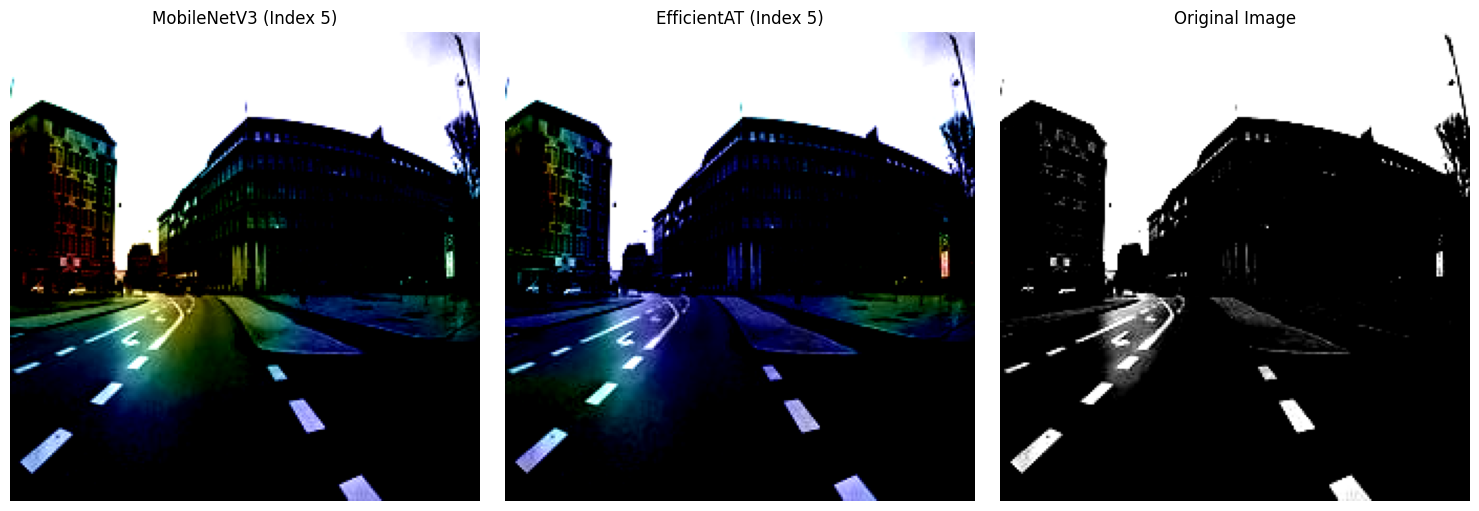

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.270742416381836..1.728795313835144].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.270742416381836..1.7390700817108153].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2317834].


[INFO] Index 6 → 0037fe3e-da51-4915-99f8-70575d4d2413.jpeg


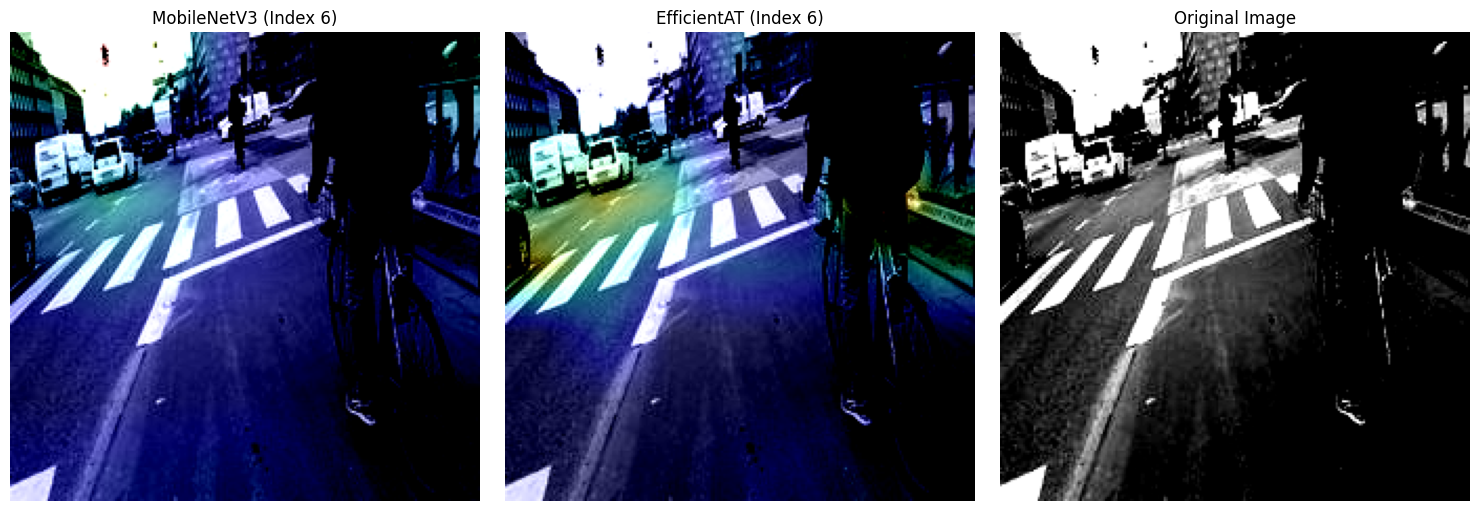

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1577190160751343..1.7390700817108153].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1577190160751343..1.7390700817108153].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.2317834].


[INFO] Index 7 → 0057a55d-b595-46cf-a1cd-204bd2f21634.jpeg


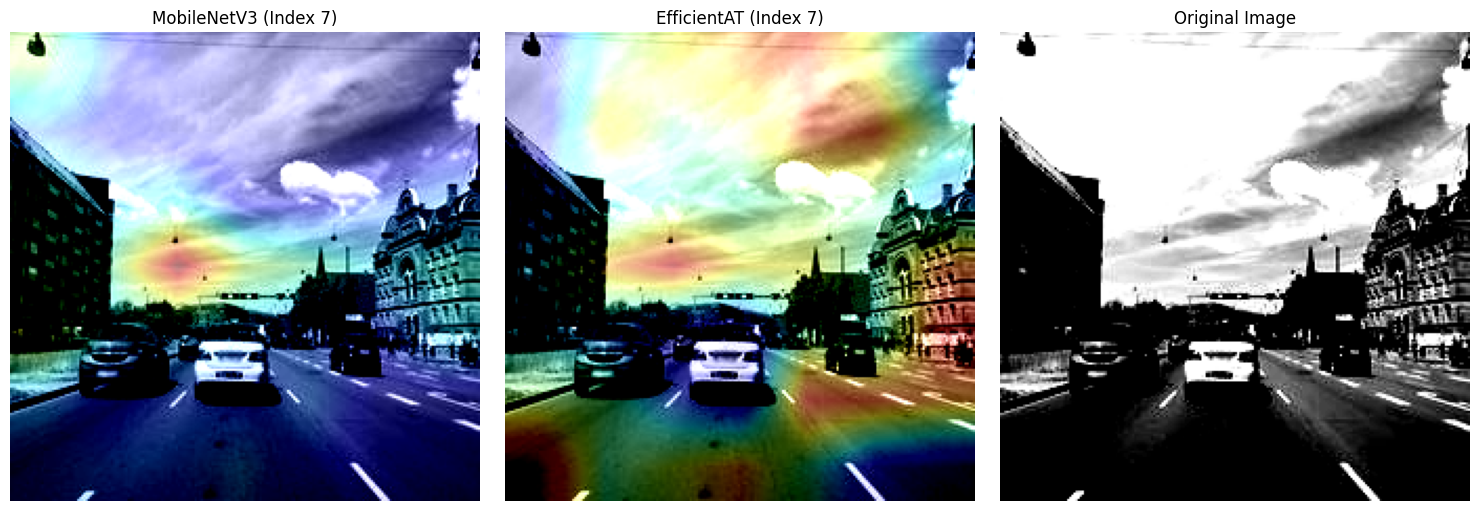

In [20]:
# target layers before the FC layer is applied
# final layer still contains spatial relationship data
# which is needed for the final visualisation

mobilenet_layer = model_grey.features[-1]
efficient_layer = model_audio.features[-1]


# create model objects from grad cam class
cam_mobilenet = GradCAM(model_grey, mobilenet_layer)
cam_audio = GradCAM(model_audio, efficient_layer)



model_grey.to(device)
model_audio.to(device)

model_grey.eval()
model_audio.eval()

for idx in range(5,8):

    image_path = get_image_by_index(idx)
    img = load_image(image_path).to(device)
    img.requires_grad_(True)

    # CAMs
    cam1 = cam_mobilenet.generate(img)
    cam2 = cam_audio.generate(img)

    # SIDE-BY-SIDE OUTPUT
    visualise(
        img,
        cam1,
        cam2,
        titles=[
            f"MobileNetV3 (Index {idx})",
            f"EfficientAT (Index {idx})",
            "Original Image"
        ]
    )